In [10]:
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO


In [11]:
base_path = "Dataset"
output_base = "result"
os.makedirs(output_base, exist_ok=True)

In [3]:
print("Loading YOLO models...")
model1 = YOLO("yolov8n.pt")
model2 = YOLO("yolov8s.pt")
model3 = YOLO("yolov8m.pt")
model4 = YOLO("yolov8l.pt")
model5 = YOLO("yolov8x.pt")
models = [model1, model2, model3, model4, model5]

Loading YOLO models...


In [12]:
total = 0
for i in range(1, 9):  # Cow counts folder 1 to 8
    for fb in ["Front", "Back"]:
        folder_path = os.path.join(base_path, str(i), fb)
        if not os.path.isdir(folder_path):
            continue
        image_count = len([img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])
        total += i * image_count

print(f"\nTotal expected cow detections in all images: {total}\n")


Total expected cow detections in all images: 346



In [ ]:
detections = []
for z, model in enumerate(models, start=1):
    model_folder = os.path.join(output_base, f"CSP_Model_{z}")

    if os.path.exists(model_folder):
        shutil.rmtree(model_folder)
    shutil.copytree(base_path, model_folder)

    total_cows_detected = 0

    for x in os.listdir(base_path):
        for y in ["Front", "Back"]:
            source_folder = os.path.join(base_path, x, y)
            target_folder = os.path.join(model_folder, x, y)

            if not os.path.isdir(source_folder):
                continue

            os.makedirs(target_folder, exist_ok=True)

            for filename in os.listdir(source_folder):
                if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                picture = os.path.join(source_folder, filename)

                # Run detection
                results = model(picture, conf=0.25, iou=0.45, imgsz=640, save=False, verbose=False)
                result = results[0]

                # Filter for class 19 (cow only)
                cow_indices = (result.boxes.cls.cpu().numpy() == 19)
                result.boxes.data = result.boxes.data[cow_indices]

                # Accumulate detections
                cow_count = result.boxes.data.shape[0]
                total_cows_detected += cow_count

                # Plot and save
                result_img = result.plot()
                output_path = os.path.join(target_folder, filename)
                cv2.imwrite(output_path, result_img)

    detections.append(total_cows_detected)
    accuracy = (total_cows_detected / total) * 100 if total > 0 else 0
    print(f"Model {z} detected {total_cows_detected} cows. Accuracy: {accuracy:.2f}%")

Model 1 detected 126 cows. Accuracy: 36.42%
Model 2 detected 191 cows. Accuracy: 55.20%
Model 3 detected 321 cows. Accuracy: 92.77%
Model 4 detected 380 cows. Accuracy: 109.83%
Model 5 detected 364 cows. Accuracy: 105.20%


YOLOv8 Cow Detection Performance


,Model Configuration,Scale,Model Size (MB),Cows Detected,Detection Accuracy (%)
0,YOLOv8n,nano,6.2,126,36.42%
1,YOLOv8s,small,21.5,191,55.20%
2,YOLOv8m,medium,49.7,321,92.77%
3,YOLOv8l,large,83.7,380,109.83%
4,YOLOv8x,extra large,130.5,364,105.20%


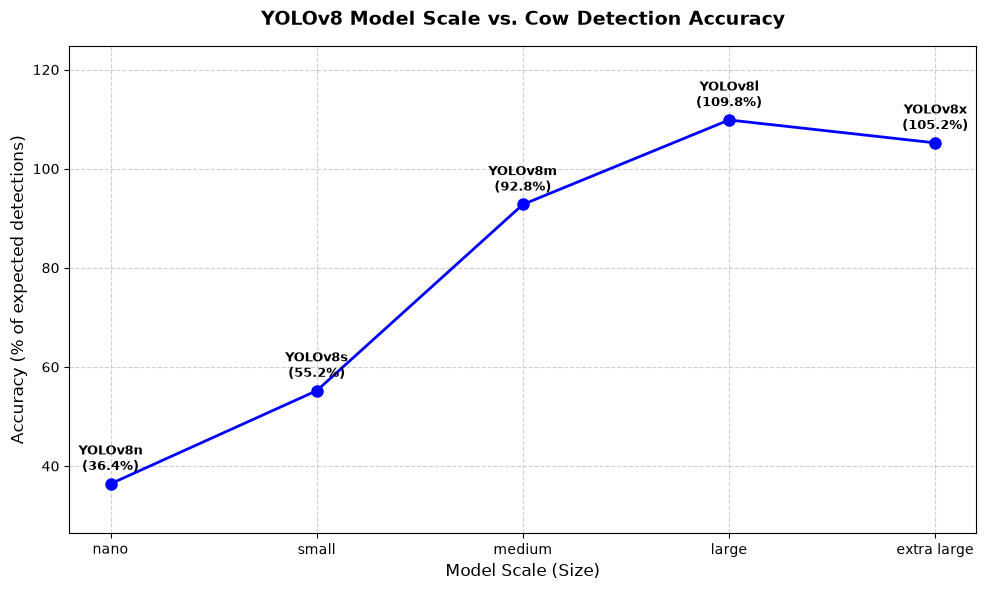

In [15]:
model_names = ["YOLOv8n", "YOLOv8s", "YOLOv8m", "YOLOv8l", "YOLOv8x"]
model_scales = ["nano", "small", "medium", "large", "extra large"]
weight_files = ["yolov8n.pt", "yolov8s.pt", "yolov8m.pt", "yolov8l.pt", "yolov8x.pt"]
model_sizes_mb = []

for file in weight_files:
    if os.path.exists(file):
        # Convert bytes to MB
        size_mb = os.path.getsize(file) / (1024 * 1024)
        model_sizes_mb.append(round(size_mb, 1))
    else:
        model_sizes_mb.append(0.0)
    
accuracies = [(count / total) * 100 for count in detections]

df_summary = pd.DataFrame({
    "Model Configuration": model_names,
    "Scale": model_scales,
    "Model Size (MB)": model_sizes_mb,
    "Cows Detected": detections,
    "Detection Accuracy (%)": [f"{acc:.2f}%" for acc in accuracies]
})

print("YOLOv8 Cow Detection Performance")
display(df_summary)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(model_scales, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
for i, (scale, acc, name) in enumerate(zip(model_scales, accuracies, model_names)):
    ax.annotate(f"{name}\n({acc:.1f}%)",
                (scale, acc),
                textcoords="offset points",
                xytext=(0,10),
                ha='center',
                fontsize=9,
                weight='bold')

ax.set_title("YOLOv8 Model Scale vs. Cow Detection Accuracy", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Model Scale (Size)", fontsize=12)
ax.set_ylabel("Accuracy (% of expected detections)", fontsize=12)
ax.set_ylim(min(accuracies) - 10, max(accuracies) + 15)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [16]:
image_dir = "image"
if os.path.exists(image_dir):
    shutil.rmtree(image_dir)
os.makedirs(image_dir, exist_ok=True)

graph_path = os.path.join(image_dir, "graph.png")
fig.savefig(graph_path, dpi=300, bbox_inches='tight')
print(f"Graph saved to: {graph_path}")

fig_table, ax_table = plt.subplots(figsize=(8, 3)) 
ax_table.axis('off')

tbl = ax_table.table(
    cellText=df_summary.values, 
    colLabels=df_summary.columns, 
    cellLoc='center', 
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)

table_path = os.path.join(image_dir, "table.png")
plt.savefig(table_path, dpi=300, bbox_inches='tight')
plt.close(fig_table)  # Close table figure to prevent display overlaps
print(f"Table image saved to: {table_path}")

Graph saved to: image/graph.png
Table image saved to: image/table.png
